# Análisis de Series Temporales de Calidad del Aire en Londres
## Modelo Predictivo con Procesos Gaussianos (GP Compuesto)

**Fuente de datos:** London Air Quality Network (LAQN)  
**Periodo:** 2013–2024  
**Estaciones:** KC1 (Marylebone Rd), KC1 (North Kensington), WM6 (Oxford St)  
**Gas objetivo:** NO₂ (µg/m³)

---
### Flujo del notebook
```
0. Instalación y librerías
1. Carga y unión de CSVs LAQN
2. Limpieza y agregación diaria
3. EDA: tendencia, estacionalidad, eventos estructurales
4. Test de estacionariedad
5. Feature engineering temporal
6. Train / Test split (temporal)
7. Escalado
8. SARIMA  ←  baseline
9. GP Compuesto (GPyTorch)
10. Comparativa y visualización final
```

## 0 · Instalación de dependencias

In [26]:
# Ejecutar solo la primera vez
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "statsmodels", "scikit-learn",
    "torch", "gpytorch",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("✅ Dependencias instaladas")

✅ Dependencias instaladas


In [27]:
# ── Imports globales ───────────────────────────────────────────────────────────
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import gpytorch
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels  import RBFKernel, PeriodicKernel, MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means    import ConstantMean
from gpytorch.models   import ExactGP
from sklearn.metrics   import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools  import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
sns.set_theme(style="whitegrid")

# ── Rutas ──────────────────────────────────────────────────────────────────────
ROOT     = Path("./")           # ajusta si el notebook está en otra carpeta
LAQN_DIR = ROOT / "data_london" / "raw" / "laqn"
SITES    = ["KC1"]
CSV_NAME = "o3_hourly_KC1_2009_2021.csv"   # nombre definido en el script de descarga

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("✅ Entorno listo")

✅ Entorno listo


---
## 1 · Carga y unión de CSVs LAQN

In [28]:
LAQN_DIR = ROOT / "data_london" / "raw" / "laqn" / "KC1"
CSV_NAME  = "o3_hourly_KC1_2009_2019.csv"

def load_laqn_site(site_code: str) -> pd.DataFrame:
    path = LAQN_DIR / CSV_NAME
    df   = pd.read_csv(path, low_memory=False)

    # El CSV está en formato largo: Site, Species, ReadingDateTime, Value, Units, ...
    df = df[df["Species"].str.strip().str.upper() == "O3"].copy()

    # Parsear fecha
    df["datetime"] = pd.to_datetime(df["ReadingDateTime"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).set_index("datetime")

    # Renombrar Value → O3 y convertir a numérico
    df = df.rename(columns={"Value": "O3"})
    df["O3"] = pd.to_numeric(df["O3"], errors="coerce")

    return df[["O3"]]


df_KC1   = load_laqn_site("KC1")
O3_clip = {"KC1": df_KC1["O3"]}

print("Rango temporal:", df_KC1.index.min(), "→", df_KC1.index.max())
print("Filas totales: ", len(df_KC1))
print("NaN:          ", df_KC1["O3"].isna().sum())
df_KC1.head()

Rango temporal: 2009-01-01 00:00:00 → 2018-12-31 23:00:00
Filas totales:  87648
NaN:           3121


,O3
datetime,
2009-01-01 00:00:00,23.9
2009-01-01 01:00:00,22.0
2009-01-01 02:00:00,27.3
2009-01-01 03:00:00,32.9
2009-01-01 04:00:00,32.4


---
## 2 · Limpieza y agregación diaria

In [29]:
# ── KC1 — única estación, serie ya cargada ────────────────────────────────────
hourly = (
    O3_clip["KC1"]       # ya es la serie O3 de KC1
    .sort_index()
    .resample("h").mean()
)

# Valores negativos o extremos → NaN
hourly = hourly.clip(lower=0)
Q99 = hourly.quantile(0.999)
hourly[hourly > Q99] = np.nan

print(f"Datos horarios: {len(hourly):,} filas | NaN: {hourly.isna().sum():,} "
      f"({hourly.isna().mean()*100:.1f}%)")

# ── Agregar a diario (media diaria, mínimo 18 h válidas) ──────────────────────
daily = (
    hourly
    .resample("D")
    .agg(lambda x: x.mean() if x.notna().sum() >= 18 else np.nan)
    .interpolate(method="time", limit=7)
    .dropna()
)

weekly = (
    hourly
    .resample("W")
    .agg(lambda x: x.mean() if x.notna().sum() >= 18 else np.nan)
    .interpolate(method="time", limit=7)
    .dropna()
)


print(f"\nSerie diaria: {len(daily):,} días | NaN restantes: {daily.isna().sum()}")
print(f"Estadísticos básicos:\n{daily.describe().round(2)}")

Datos horarios: 87,648 filas | NaN: 3,206 (3.7%)

Serie diaria: 3,626 días | NaN restantes: 0
Estadísticos básicos:
count    3626.00
mean       39.09
std        18.67
min         0.08
25%        25.56
50%        39.52
75%        52.90
max        97.57
Name: O3, dtype: float64



## 5 · Feature engineering temporal

In [30]:
def make_features(series: pd.Series) -> pd.DataFrame:
    """
    Construye la matriz X con features temporales cíclicas y lags.
    Permite que el GP capture tendencia, estacionalidad y autocorrelación
    sin depender solo de la posición temporal.
    """
    idx = series.index
    feat = pd.DataFrame(index=idx)

    # Tendencia lineal normalizada [0, 1]
    feat["t"] = np.linspace(0, 1, len(idx))

    # Estacionalidad semanal (periodo = 7 días)
    feat["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
    feat["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)

    # Estacionalidad anual (periodo = 365 días)
    feat["doy_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    feat["doy_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)

    # Mes (componente anual más gruesa)
    feat["month_sin"] = np.sin(2 * np.pi * idx.month / 12)
    feat["month_cos"] = np.cos(2 * np.pi * idx.month / 12)

    # Lags autorregresivos (días anteriores)
    feat["lag_1"]   = series.shift(1).values
    feat["lag_7"]   = series.shift(7).values    # una semana
    feat["lag_30"]  = series.shift(30).values   # un mes
    feat["lag_365"] = series.shift(365).values  # un año

    # Media móvil reciente (proxy de contexto local)
    feat["ma_7"]  = series.shift(1).rolling(7,  min_periods=1).mean().values
    feat["ma_30"] = series.shift(1).rolling(30, min_periods=1).mean().values

    return feat.dropna()


features = make_features(daily)
target   = daily[features.index]   # alinear y con X tras dropna

print(f"Features: {features.shape[1]} columnas, {len(features):,} filas")
features.head()

Features: 13 columnas, 3,261 filas


,t,dow_sin,dow_cos,doy_sin,doy_cos,month_sin,month_cos,lag_1,lag_7,lag_30,lag_365,ma_7,ma_30
datetime,,,,,,,,,,,,,
2010-01-01,0.100690,-0.433884,-0.900969,0.017202,0.999852,0.5,0.866025,46.962500,19.600000,24.386364,16.975000,30.115192,26.205161
2010-01-02,0.100966,-0.974928,-0.222521,0.034398,0.999408,0.5,0.866025,36.120833,54.925000,27.983333,15.691667,32.475311,26.596310
2010-01-03,0.101241,-0.781831,0.623490,0.051584,0.998669,0.5,0.866025,19.266667,53.816667,17.204167,11.250000,27.381263,26.305754
2010-01-04,0.101517,0.000000,1.000000,0.068755,0.997634,0.5,0.866025,19.008333,10.054167,43.204167,1.687500,22.408644,26.365893
2010-01-05,0.101793,0.781831,0.623490,0.085906,0.996303,0.5,0.866025,11.083333,15.895833,58.600000,20.412500,22.555668,25.295199


In [31]:
def make_features_weekly(series: pd.Series) -> pd.DataFrame:
    """
    Construye la matriz X con features temporales cíclicas y lags 
    adaptados a una frecuencia SEMANAL.
    """
    idx = series.index
    feat = pd.DataFrame(index=idx)

    # 1. Tendencia lineal normalizada [0, 1]
    feat["t"] = np.linspace(0, 1, len(idx))

    # 2. Estacionalidad Mensual (aprox. 4.34 semanas por mes)
    # Útil si hay patrones que se repiten cada mes
    feat["week_month_sin"] = np.sin(2 * np.pi * idx.day / 30.44)
    feat["week_month_cos"] = np.cos(2 * np.pi * idx.day / 30.44)

    # 3. Estacionalidad Anual (periodo = 52.18 semanas)
    # Usamos isocalendar().week para obtener el número de semana del año (1-53)
    weeks_in_year = idx.isocalendar().week
    feat["year_sin"] = np.sin(2 * np.pi * weeks_in_year / 52.18)
    feat["year_cos"] = np.cos(2 * np.pi * weeks_in_year / 52.18)

    # 4. Lags autorregresivos (en semanas)
    feat["lag_1"] = series.shift(1).values   # 1 semana atrás
    feat["lag_4"] = series.shift(4).values   # 4 semanas atrás (~1 mes)
    feat["lag_12"] = series.shift(12).values # 12 semanas atrás (~1 trimestre)
    feat["lag_52"] = series.shift(52).values # 52 semanas atrás (1 año)
    feat["lag_104"] = series.shift(104).values # 104 semanas atrás (2 años)

    # 5. Media móvil reciente (Smoothing semanal)
    # Representa el comportamiento de las últimas 4 y 12 semanas
    feat["ma_4"]  = series.shift(1).rolling(4,  min_periods=1).mean().values
    feat["ma_12"] = series.shift(1).rolling(12, min_periods=1).mean().values

    return feat.dropna()
features = make_features_weekly (weekly)
target   = weekly[features.index]   # alinear y con X tras dropna

print(f"Features: {features.shape[1]} columnas, {len(features):,} filas")
features.head()

Features: 12 columnas, 419 filas


,t,week_month_sin,week_month_cos,year_sin,year_cos,lag_1,lag_4,lag_12,lag_52,lag_104,ma_4,ma_12
datetime,,,,,,,,,,,,
2011-01-02,0.199234,0.401198,0.915991,-0.021673,0.999765,12.621557,19.374096,17.849351,22.485629,11.401042,13.692966,20.489860
2011-01-09,0.201149,0.959122,-0.282993,0.120123,0.992759,14.865476,11.372619,38.077381,26.876786,10.202381,12.565811,20.241204
2011-01-16,0.203065,-0.160307,-0.987067,0.238506,0.971141,20.319760,11.403593,24.005988,13.122609,33.477108,14.802597,18.761402
2011-01-23,0.204981,-0.999384,0.035083,0.353435,0.935459,35.256548,12.621557,29.293939,8.790909,30.817308,20.765835,19.698949
2011-01-30,0.206897,-0.090697,0.995879,0.463246,0.88623,19.256627,14.865476,32.319048,18.577914,15.948795,22.424603,18.862506


---
## 6 · Train / Test split temporal (80 / 20)

Train: 2011-01-02 → 2016-12-25 (313 semanas)
Test : 2017-01-01  → 2019-01-06  (106 semanas)


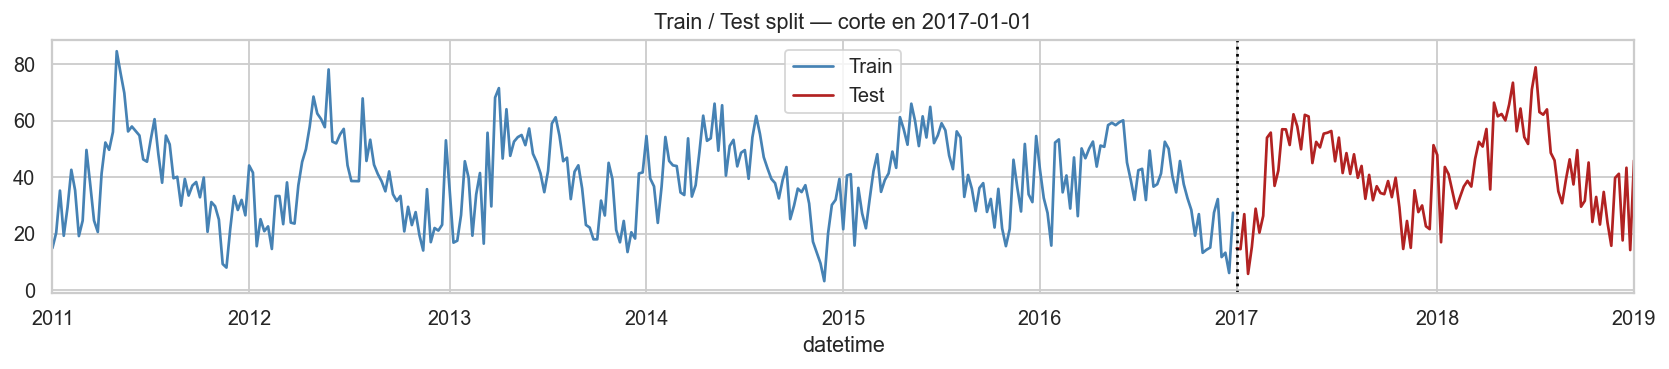

In [32]:
import pandas as pd
split_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2020-12-31')

X_train_df = features[features.index < split_date]
X_test_df  = features[(features.index >= split_date) & (features.index <= end_date)]
y_train    = target[target.index < split_date]
y_test     = target[(target.index >= split_date) & (target.index <= end_date)]

n_train = len(y_train)

print(f"Train: {y_train.index[0].date()} → {y_train.index[-1].date()} ({n_train:,} semanas)")
print(f"Test : {y_test.index[0].date()}  → {y_test.index[-1].date()}  ({len(y_test):,} semanas)")

# Visualización del split
fig, ax = plt.subplots(figsize=(13, 3))
y_train.plot(ax=ax, color="steelblue", label="Train")
y_test.plot( ax=ax, color="firebrick",  label="Test")
ax.axvline(split_date, color="black", ls=":", lw=1.5)
ax.set_title(f"Train / Test split — corte en {split_date.date()}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 7 · Escalado

In [33]:
# ── Escalar X ─────────────────────────────────────────────────────────────────
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_df)
X_test_scaled  = scaler_X.transform(X_test_df)

# ── Escalar y (guardar media y std para desescalar después) ───────────────────
y_mean = float(y_train.mean())
y_std  = float(y_train.std())
y_train_scaled = (y_train.values - y_mean) / y_std
y_test_scaled  = (y_test.values  - y_mean) / y_std

# ── Convertir a tensores PyTorch ──────────────────────────────────────────────
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32)

print(f"X_train: {X_train_t.shape}  |  y_train: {y_train_t.shape}")
print(f"X_test : {X_test_t.shape}   |  y_test : {y_test_t.shape}")
print(f"y_mean={y_mean:.2f} µg/m³, y_std={y_std:.2f} µg/m³")

X_train: torch.Size([313, 12])  |  y_train: torch.Size([313])
X_test : torch.Size([106, 12])   |  y_test : torch.Size([106])
y_mean=39.27 µg/m³, y_std=14.71 µg/m³


---
## 9 · GP Compuesto (GPyTorch)

**Kernel:**  
$$k(x,x') = k_{\text{RBF}} + k_{\text{Periódico}} + k_{\text{Matérn}}$$

| Componente | Captura |
|---|---|
| RBF (Radial Basis Function) | Tendencia suave a largo plazo |
| Periódico | Estacionalidad (semanal / anual via features cíclicas) |
| Matérn ν=2.5 | Variaciones locales no suaves, episodios de contaminación |

In [34]:
class CompositeGP(ExactGP):
    """GP con kernel compuesto: RBF + Periódico + Matérn."""

    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()

        # Componente 1: tendencia suave
        k_rbf = ScaleKernel(RBFKernel())

        # Componente 2: estacionalidad (features cíclicas → periodicidad implícita)
        k_per = ScaleKernel(PeriodicKernel())

        # Componente 3: variaciones locales (Matérn 5/2)
        k_mat = ScaleKernel(MaternKernel(nu=2.5))

        self.covar_module = k_rbf + k_per + k_mat

    def forward(self, x):
        mean_x  = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)


likelihood = GaussianLikelihood()
gp_model   = CompositeGP(X_train_t, y_train_t, likelihood)

# Resumen de parámetros
total_params = sum(p.numel() for p in gp_model.parameters())
print(f"Parámetros del GP: {total_params}")
print("Estructura del kernel:", gp_model.covar_module)

Parámetros del GP: 9
Estructura del kernel: AdditiveKernel(
  (kernels): ModuleList(
    (0): ScaleKernel(
      (base_kernel): RBFKernel(
        (raw_lengthscale_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
    (1): ScaleKernel(
      (base_kernel): PeriodicKernel(
        (raw_lengthscale_constraint): Positive()
        (raw_period_length_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
    (2): ScaleKernel(
      (base_kernel): MaternKernel(
        (raw_lengthscale_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
  )
)


Entrenando GP Compuesto...
  Época  100/500  |  Loss: 1.0635
  Época  200/500  |  Loss: 1.0532
  Época  300/500  |  Loss: 1.0500
  Época  400/500  |  Loss: 1.0486
  Época  500/500  |  Loss: 1.0479

✅ Entrenamiento completado


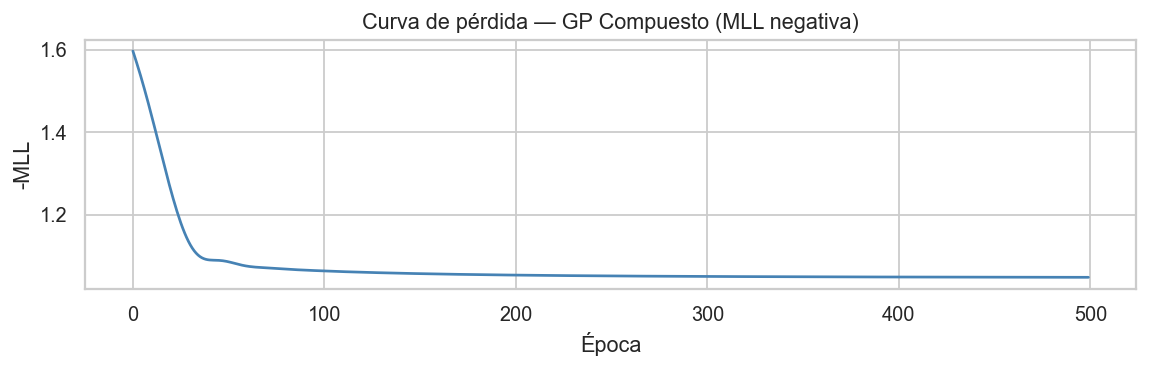

In [35]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
gp_model.train()
likelihood.train()

optimizer = torch.optim.Adam(gp_model.parameters(), lr=0.05)
mll       = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gp_model)

NUM_EPOCHS = 500
losses = []

print("Entrenando GP Compuesto...")
for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    output = gp_model(X_train_t)
    loss   = -mll(output, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"  Época {epoch+1:>4}/{NUM_EPOCHS}  |  Loss: {loss.item():.4f}")

print("\n✅ Entrenamiento completado")

# Curva de pérdida
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(losses, color="steelblue", lw=1.5)
ax.set_title("Curva de pérdida — GP Compuesto (MLL negativa)")
ax.set_xlabel("Época")
ax.set_ylabel("-MLL")
plt.tight_layout()
plt.show()

In [36]:
# ── Predicción ────────────────────────────────────────────────────────────────
gp_model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    preds = likelihood(gp_model(X_test_t))
    gp_mean_scaled = preds.mean.numpy()
    gp_std_scaled  = preds.stddev.numpy()

# Desescalar
gp_mean = gp_mean_scaled * y_std + y_mean
gp_std  = gp_std_scaled  * y_std
gp_lower = gp_mean - 1.96 * gp_std   # IC 95%
gp_upper = gp_mean + 1.96 * gp_std

# ── Métricas ──────────────────────────────────────────────────────────────────
mae_gp  = mean_absolute_error(y_test, gp_mean)
rmse_gp = np.sqrt(mean_squared_error(y_test, gp_mean))
r2_gp   = r2_score(y_test, gp_mean)

print(f"GP Compuesto  →  MAE: {mae_gp:.2f} µg/m³ | RMSE: {rmse_gp:.2f} µg/m³ | R²: {r2_gp:.4f}")

GP Compuesto  →  MAE: 8.26 µg/m³ | RMSE: 10.24 µg/m³ | R²: 0.5522


Métricas en Test:
MAE:  8.26 µg/m³
RMSE: 10.24 µg/m³



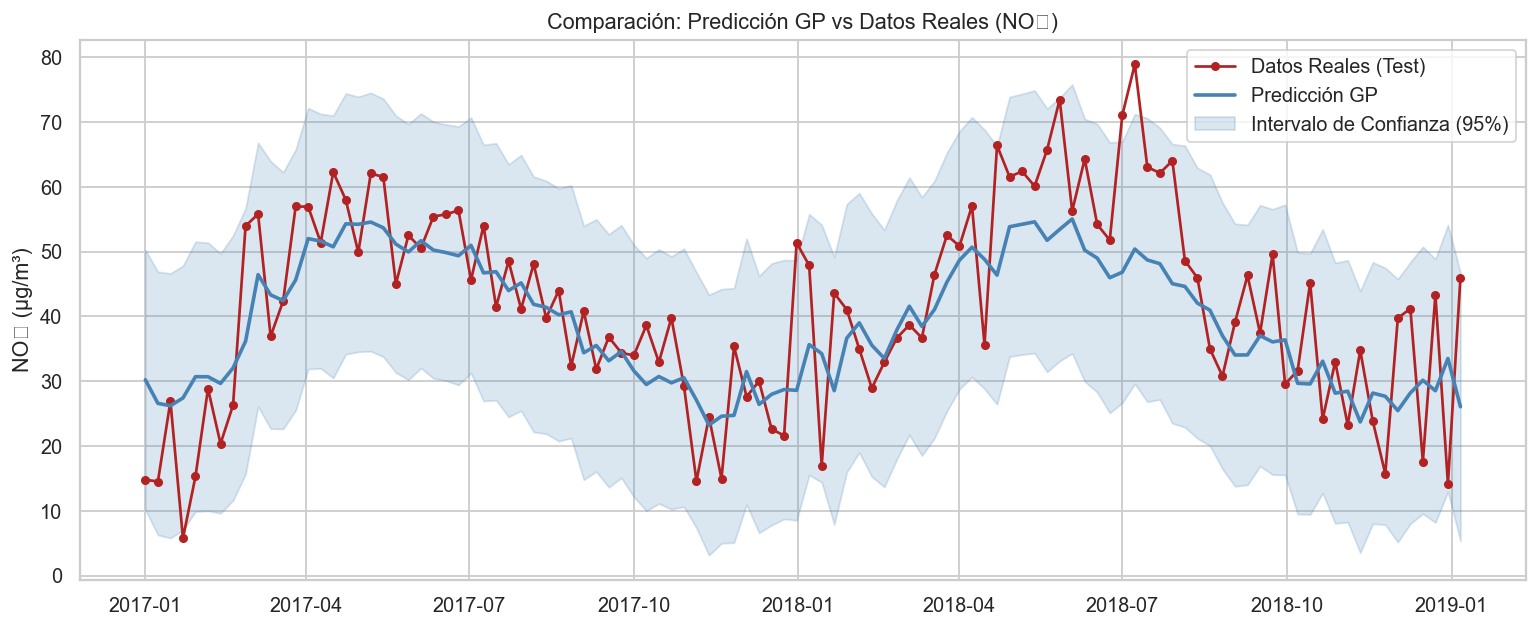

In [37]:
# ── 10 · Evaluación y comparación (Test) ───────────────────────────────────────
gp_model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Realizar predicciones sobre el conjunto de test
    observed_pred = likelihood(gp_model(X_test_t))

# Extraer medias e intervalos de confianza y desescalar a los valores originales
pred_mean_scaled = observed_pred.mean.numpy()
pred_mean_orig = (pred_mean_scaled * y_std) + y_mean
y_test_orig = (y_test_t.numpy() * y_std) + y_mean

lower_scaled, upper_scaled = observed_pred.confidence_region()
lower_orig = (lower_scaled.numpy() * y_std) + y_mean
upper_orig = (upper_scaled.numpy() * y_std) + y_mean

# Calcular métricas
mae = mean_absolute_error(y_test_orig, pred_mean_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, pred_mean_orig))
print(f"Métricas en Test:")
print(f"MAE:  {mae:.2f} µg/m³")
print(f"RMSE: {rmse:.2f} µg/m³\n")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_test.index, y_test_orig, label='Datos Reales (Test)', color='firebrick', marker='o', markersize=4)
ax.plot(y_test.index, pred_mean_orig, label='Predicción GP', color='steelblue', lw=2)
ax.fill_between(y_test.index, lower_orig, upper_orig, color='steelblue', alpha=0.2, label='Intervalo de Confianza (95%)')

ax.set_title('Comparación: Predicción GP vs Datos Reales (NO₂)')
ax.set_ylabel('NO₂ (µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()
